# Notebook 02 — LISTA, ALISTA & HyperLISTA: Training and Comparison

**Part A** — learned models on synthetic sparse recovery.

This notebook:
1. Trains LISTA end-to-end via BPTT
2. Trains ALISTA (analytic W, learnable γ, θ)
3. Tunes HyperLISTA via two-stage grid search
4. Plots NMSE (dB) vs. layer for all five methods
5. Produces a summary metrics table

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import matplotlib.pyplot as plt

from src.data.sparse_generator import build_sparse_dataloaders
from src.models.ista       import ISTA
from src.models.fista      import FISTA
from src.models.lista      import LISTA
from src.models.alista     import ALISTA
from src.models.hyperlista import HyperLISTA
from src.training.trainer  import train
from src.training.tuner    import tune_hyperlista
from src.evaluation.metrics    import evaluate_model
from src.evaluation.visualizer import plot_nmse_vs_layers, get_layerwise_nmse

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_LAYERS = 16
LAM      = 0.1

print('Device:', DEVICE)

Device: cuda


## 1. Data

In [2]:
M, N, S = 250, 500, 50

A, train_loader, val_loader, test_loader = build_sparse_dataloaders(
    m=M, n=N, s=S, sigma=0.0,
    n_train=51200, n_val=2048, n_test=2048,
    batch_size=256, device=DEVICE,
)
print(f'Dataset ready. Train batches: {len(train_loader)}')

Dataset ready. Train batches: 200


## 2. Classical Baselines (no training)

In [3]:
ista  = ISTA(A, lam=LAM, n_iter=N_LAYERS).to(DEVICE)
fista = FISTA(A, lam=LAM, n_iter=N_LAYERS).to(DEVICE)

ista_nmse  = get_layerwise_nmse(ista,  test_loader, DEVICE)
fista_nmse = get_layerwise_nmse(fista, test_loader, DEVICE)

## 3. Train LISTA

In [4]:
lista = LISTA(A, n_layers=N_LAYERS, tied=False, lam=LAM).to(DEVICE)

history_lista = train(
    lista,
    train_loader,
    val_loader,
    n_epochs=50,
    lr=1e-3,
    weight_decay=0.0,
    intermediate_weight=0.0,
    device=DEVICE,
    patience=15,
    verbose=True,
)

lista_nmse = get_layerwise_nmse(lista, test_loader, DEVICE)
print(f'LISTA final NMSE: {lista_nmse[-1]:.2f} dB')

Training: 100%|██████████| 50/50 [06:10<00:00,  7.40s/epoch, lr=5.00e-04, train_loss=0.0007, val_nmse=-20.83 dB]

LISTA final NMSE: -20.87 dB


In [5]:
import os
CKPT_DIR = "../results/notebook_02/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

torch.save(A.detach().cpu(), f"{CKPT_DIR}/A_partA.pt")
torch.save(lista.state_dict(), f"{CKPT_DIR}/lista_partA.pt")

print('LISTA checkpoint saved.')

LISTA checkpoint saved.


## 4. Train ALISTA

In [6]:
# Note: ALISTA weight computation may take a few minutes
alista = ALISTA(A, n_layers=N_LAYERS, W_iters=2000).to(DEVICE)

history_alista = train(
    alista, train_loader, val_loader,
    n_epochs=50, lr=5e-4, device=DEVICE, patience=15, verbose=True,
)
alista_nmse = get_layerwise_nmse(alista, test_loader, DEVICE)
print(f'ALISTA final NMSE: {alista_nmse[-1]:.2f} dB')

torch.save(alista.state_dict(), f"{CKPT_DIR}/alista_partA.pt")
print('ALISTA checkpoint saved.')

Training: 100%|██████████| 50/50 [11:31<00:00, 13.83s/epoch, lr=5.00e-04, train_loss=0.0001, val_nmse=-29.74 dB]


ALISTA final NMSE: -29.76 dB
ALISTA checkpoint saved.


## 5. Tune HyperLISTA

In [7]:
import json
hyperlista = HyperLISTA(A, n_layers=N_LAYERS, W_iters=2000).to(DEVICE)

tune_result = tune_hyperlista(
    hyperlista, val_loader, DEVICE,
    coarse_points=5, fine_points=7, verbose=True,
)
print('Tuned hyperparams:', tune_result)
hyperlista_nmse = get_layerwise_nmse(hyperlista, test_loader, DEVICE)
print(f'HyperLISTA final NMSE: {hyperlista_nmse[-1]:.2f} dB')

with open(f"{CKPT_DIR}/hyperlista_partA_hparams.json", "w") as f:
    json.dump(
        {
            "c1": float(hyperlista.c1),
            "c2": float(hyperlista.c2),
            "c3": float(hyperlista.c3),
        },
        f,
        indent=2,
    )

print(f'HyperLISTA hyperparams saved: c1={hyperlista.c1:.4f}, c2={hyperlista.c2:.4f}, c3={hyperlista.c3:.4f}')

=== Stage 1: Coarse grid search ===


Coarse grid: 100%|██████████| 125/125 [00:20<00:00,  6.11it/s, best_nmse=-61.72 dB]


Coarse best: c1=0.0447, c2=0.0224, c3=3.8730  NMSE=-61.72 dB  (20.5s)

=== Stage 2: Fine grid search ===


Coarse grid: 100%|██████████| 343/343 [02:03<00:00,  2.77it/s, best_nmse=-61.05 dB]


Fine best:   c1=0.0447, c2=0.0224, c3=3.8730  NMSE=-61.05 dB  (123.8s)
Tuned hyperparams: {'c1': 0.044721359549995794, 'c2': 0.022360679774997897, 'c3': 3.8729833462074175, 'nmse_db': -61.0502827167511}
HyperLISTA final NMSE: -61.39 dB
HyperLISTA hyperparams saved: c1=0.0447, c2=0.0224, c3=3.8730


## 6. NMSE vs. Layer — All Methods

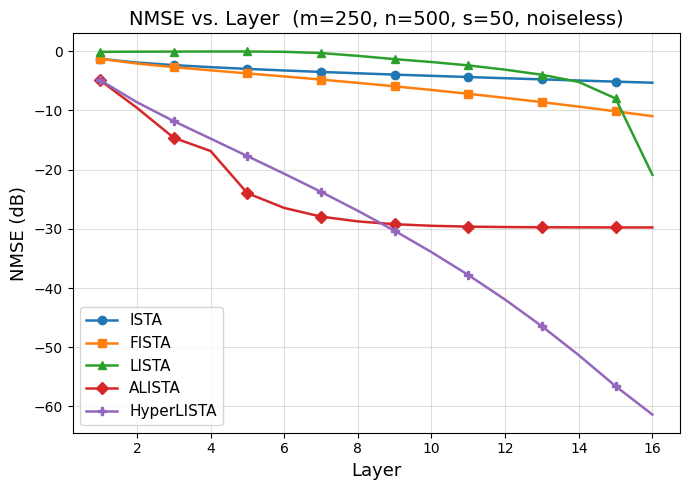

In [8]:
import os
os.makedirs('../results/notebook_02/sparse', exist_ok=True)

all_results = {
    'ISTA':       ista_nmse,
    'FISTA':      fista_nmse,
    'LISTA':      lista_nmse,
    'ALISTA':     alista_nmse,
    'HyperLISTA': hyperlista_nmse,
}

fig = plot_nmse_vs_layers(
    all_results,
    title=f'NMSE vs. Layer  (m={M}, n={N}, s={S}, noiseless)',
)
fig.savefig('../results/notebook_02/sparse/nmse_vs_layers_partA.pdf', bbox_inches='tight')
plt.show()

## 7. Summary Table

In [9]:
import pandas as pd

rows = []
for name, model in [
    ('ISTA', ista), ('FISTA', fista),
    ('LISTA', lista), ('ALISTA', alista),
    ('HyperLISTA', hyperlista),
]:
    res = evaluate_model(model, test_loader, DEVICE)
    rows.append({'Model': name, **res})

df = pd.DataFrame(rows).set_index('Model')
print(df[['nmse_db', 'runtime_ms', 'n_params']].round(3).to_string())

            nmse_db  runtime_ms  n_params
Model                                    
ISTA         -5.306       8.132         0
FISTA       -10.959       7.895         0
LISTA       -20.866       8.576   6000016
ALISTA      -29.763      18.633        32
HyperLISTA  -61.386      47.034         3
